In [1]:
import torch

In [2]:
import datetime
import feedparser
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import yfinance as yf

from datetime import datetime, timedelta
from scipy.special import softmax
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.preprocessing import MinMaxScaler
from transformers import AutoTokenizer, AutoModelForSequenceClassification

api_key = "f89ee79ae79a47e7a7deaed69f638dbe"  # Replace with your actual News API key
#this code fetches and displays news articles related to the Dollar using Yahoo Finance, Google News RSS feed, and News API.

In [3]:
# Create a Ticker object for Bitcoin and access the news data
dollar = yf.Ticker("DX-Y.NYB")
news_data = dollar.news

# Print the desired information for each article
for article in news_data:
    content = article.get('content')
    if content:
        # Assuming title, publisher, link are now within 'content'
        print("Published Time:", content.get('pubDate'))
        print("Title:", content.get('title'))  
        print("Publisher:", content.get('provider').get('displayName'))  
        print("Link:", content.get('canonicalUrl').get('url'))
        print("Content Type:", content.get('contentType'))
        print("-" * 30)
        #this code fetches and displays news articles related to the Dollar using Yahoo Finance.

Published Time: 2025-12-20T11:05:01Z
Title: Exclusive: Beyond trading: where crypto’s next real revenues may come from in 2026
Publisher: Investing.com
Link: https://finance.yahoo.com/news/exclusive-beyond-trading-where-crypto-110501171.html
Content Type: STORY
------------------------------
Published Time: 2025-12-20T03:06:03Z
Title: US Dollar Price Annual Forecast: Will 2026 be a Year of Transition?
Publisher: BeInCrypto
Link: https://beincrypto.com/us-dollar-price-prediction-2026/
Content Type: STORY
------------------------------
Published Time: 2025-12-19T22:29:06Z
Title: Cotton Closes with Gains on Friday
Publisher: Barchart
Link: https://www.barchart.com/story/news/36722729/cotton-closes-with-gains-on-friday
Content Type: STORY
------------------------------
Published Time: 2025-12-19T22:08:33Z
Title: Coinbase, Ripple urge Senate Committee to preserve 'genius' rewards
Publisher: TheStreet
Link: https://www.thestreet.com/crypto/policy/coinbase-ripple-urge-senate-committe-to-prese

In [4]:
# Define RSS feed URL and retrieve feed
query = "Dollar_index"
rss_url = f"https://news.google.com/rss/search?q={query}t&hl=en-US&gl=US&ceid=US:en"
feed = feedparser.parse(rss_url)

for entry in feed.entries:
    print("Published:", entry.published)
    print("Title:", entry.title)
    print("Link:", entry.link)
    print("-" * 30)
    #this code fetches and displays news articles related to the Dollar using Yahoo Finance and Google News RSS feed.

In [5]:
# Define News API variables
query = "Dollar index"
url = f"https://newsapi.org/v2/everything?q={query}&apiKey={api_key}&language=en"
response = requests.get(url)

# Get news data
results = []
if response.status_code == 200:
    news_data = response.json()
    for article in news_data['articles']:
        results.append({
            'Date': article['publishedAt'][:10],  # Extract date
            'URL': article['url'],
            'Source': article['source']['name'],
            'Author': article['author'],
            'Title': article['title'],
            'Description': article['description'],
            'Content': article['content']
        })
else:
    print("Error fetching news:", response.status_code)

# Create DataFrame
df = pd.DataFrame(results)
df
#This code fetches and displays news articles related to the Dollar using Yahoo Finance, Google News RSS feed, and News API.

,Date,URL,Source,Author,Title,Description,Content
0,2025-11-26,https://finance.yahoo.com/news/gold-etfs-inves...,Yahoo Entertainment,Yashwardhan Jain,Gold ETFs That Investors Can Consider as the M...,"Gold's rally shows no signs of slowing, with E...",The yellow metal is already up about 58.71% ye...
1,2025-12-08,https://uk.finance.yahoo.com/news/gold-price-o...,Yahoo Entertainment,Pedro Goncalves,"Gold back above $4,200 as Fed cut bets rise","The weak dollar supported demand for bullion, ...",Gold prices were mixed on Monday morning but w...
2,2025-12-19,https://www.barrons.com/livecoverage/stock-mar...,Barron's,"Giulia Petroni, Dow Jones Newswires",Gold Headed for Weekly Gain on U.S. Rate-Cut Bets,"The Dow, S&P 500, and Nasdaq are rising in pre...",Gold prices slipped in early trading on a firm...
3,2025-11-30,https://finance.yahoo.com/news/stocks-drift-ba...,Yahoo Entertainment,Jake Conley,Stocks drift back toward record highs as the f...,"As the market moves into December, investors w...",The final month of the year gets underway on M...
4,2025-11-24,https://finance.yahoo.com/news/asian-stocks-ri...,Yahoo Entertainment,AFP,Asian stocks rise as US rate hopes soothe nerv...,Asian markets mostly rose Monday as fresh hope...,Investors are awaiting the latest US inflation...
...,...,...,...,...,...,...,...
94,2025-12-14,https://www.thestreet.com/retail/kroger-ceo-fl...,TheStreet,Daniel Kline,Kroger CEO flags alarming shift in how custome...,"People need to eat, but what they eat depends ...","People need to eat, but what they eat depends ..."
95,2025-12-16,https://consent.yahoo.com/v2/collectConsent?se...,Yahoo Entertainment,None,Where is the Dollar Index Heading in 2026?,None,"If you click 'Accept all', we and our partners..."
96,2025-11-28,https://finance.yahoo.com/news/live/stock-mark...,Yahoo Entertainment,Rian Howlett,"Stock market today: S&P 500, Dow rise to end a...",US stocks rose for the fifth day in a row on F...,US stocks rose during a holiday-shortened trad...
97,2025-11-21,https://finance.yahoo.com/news/yen-gets-lift-v...,Yahoo Entertainment,By Ozan Ergenay and Rae Wee,Yen gets a lift as verbal intervention picks u...,By Ozan Ergenay and Rae Wee LONDON (Reuters) -...,By Ozan Ergenay and Rae Wee\r\nLONDON (Reuters...


In [6]:
# Save News dataset
df.to_csv('news_data.csv', index=False)

In [7]:
# Specify the FinBERT model
MODEL = f"ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

# Text processing function
def preprocess(text):
    if text is None: # Handle None values by returning an empty string if text is None
        return ""
    new_text = []
    for t in text.split(" "):
        t = '' if t.startswith('#') and len(t) > 1 else t  # remove hashtags
        t = '' if t.startswith('@') and len(t) > 1 else t  # remove usernames
        t = '' if t.startswith('http') else t  # remove URLs
        new_text.append(t)
    return " ".join(new_text)

# Sentiment scoring function
def get_sentiment(text):
    text = preprocess(text)
    encoded_input = tokenizer(text, return_tensors='pt')
    output = model(**encoded_input)
    scores = output[0][0].detach().numpy()
    scores = softmax(scores)
    return {
        'positive': scores[0],
        'negative': scores[1],
        'neutral': scores[2]
    }
#this code uses the finbert model to analyze sentiment of news articles related to the Dollar.

In [8]:
# Remove rows with "[Removed]" or None in Description
df = df[df['Description'] != '[Removed]']
df = df.dropna(subset=['Description'])

# Apply sentiment scoring to the 'description' column and create new columns
df.loc[:, 'Sent_positive'] = df['Description'].apply(lambda x: get_sentiment(x)['positive'])
df.loc[:, 'Sent_negative'] = df['Description'].apply(lambda x: get_sentiment(x)['negative'])
df.loc[:, 'Sent_neutral'] = df['Description'].apply(lambda x: get_sentiment(x)['neutral'])
df

,Date,URL,Source,Author,Title,Description,Content,Sent_positive,Sent_negative,Sent_neutral
0,2025-11-26,https://finance.yahoo.com/news/gold-etfs-inves...,Yahoo Entertainment,Yashwardhan Jain,Gold ETFs That Investors Can Consider as the M...,"Gold's rally shows no signs of slowing, with E...",The yellow metal is already up about 58.71% ye...,0.211887,0.746981,0.041132
1,2025-12-08,https://uk.finance.yahoo.com/news/gold-price-o...,Yahoo Entertainment,Pedro Goncalves,"Gold back above $4,200 as Fed cut bets rise","The weak dollar supported demand for bullion, ...",Gold prices were mixed on Monday morning but w...,0.292161,0.668064,0.039775
2,2025-12-19,https://www.barrons.com/livecoverage/stock-mar...,Barron's,"Giulia Petroni, Dow Jones Newswires",Gold Headed for Weekly Gain on U.S. Rate-Cut Bets,"The Dow, S&P 500, and Nasdaq are rising in pre...",Gold prices slipped in early trading on a firm...,0.759420,0.070596,0.169985
3,2025-11-30,https://finance.yahoo.com/news/stocks-drift-ba...,Yahoo Entertainment,Jake Conley,Stocks drift back toward record highs as the f...,"As the market moves into December, investors w...",The final month of the year gets underway on M...,0.485300,0.111769,0.402931
4,2025-11-24,https://finance.yahoo.com/news/asian-stocks-ri...,Yahoo Entertainment,AFP,Asian stocks rise as US rate hopes soothe nerv...,Asian markets mostly rose Monday as fresh hope...,Investors are awaiting the latest US inflation...,0.862675,0.107222,0.030103
...,...,...,...,...,...,...,...,...,...,...
93,2025-12-04,https://finance.yahoo.com/news/asian-shares-mi...,Yahoo Entertainment,STAN CHOE,Wall Street inches closer to its all-time high,Dollar General helped lead the market and rall...,NEW YORK (AP) The U.S. stock market held near ...,0.953621,0.022336,0.024043
94,2025-12-14,https://www.thestreet.com/retail/kroger-ceo-fl...,TheStreet,Daniel Kline,Kroger CEO flags alarming shift in how custome...,"People need to eat, but what they eat depends ...","People need to eat, but what they eat depends ...",0.077090,0.089133,0.833777
96,2025-11-28,https://finance.yahoo.com/news/live/stock-mark...,Yahoo Entertainment,Rian Howlett,"Stock market today: S&P 500, Dow rise to end a...",US stocks rose for the fifth day in a row on F...,US stocks rose during a holiday-shortened trad...,0.927485,0.042064,0.030451
97,2025-11-21,https://finance.yahoo.com/news/yen-gets-lift-v...,Yahoo Entertainment,By Ozan Ergenay and Rae Wee,Yen gets a lift as verbal intervention picks u...,By Ozan Ergenay and Rae Wee LONDON (Reuters) -...,By Ozan Ergenay and Rae Wee\r\nLONDON (Reuters...,0.943699,0.033010,0.023290


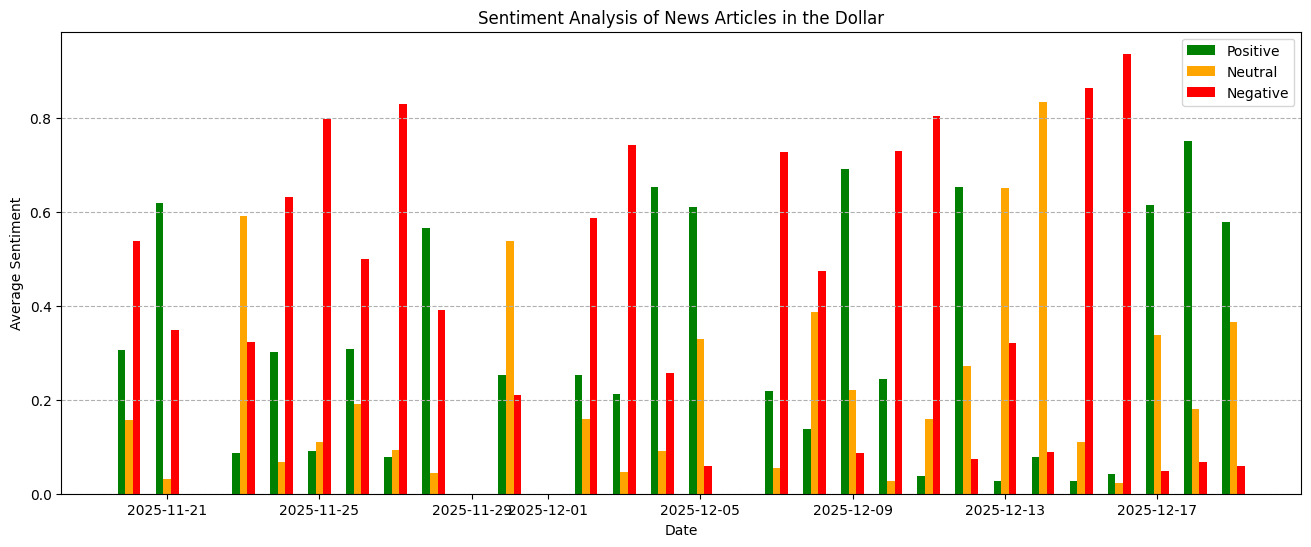

In [9]:
# Group by date and calculate average sentiment scores
df_grouped = df.groupby('Date').agg(['sum', 'count'])  # Get sum and count

# Create new columns for normalized sentiment scores
df_grouped['avg_positive'] = df_grouped['Sent_positive']['sum'] / df_grouped['Sent_positive']['count']  # Normalize positive
df_grouped['avg_negative'] = df_grouped['Sent_negative']['sum'] / df_grouped['Sent_negative']['count']  # Normalize negative
df_grouped['avg_neutral'] = df_grouped['Sent_neutral']['sum'] / df_grouped['Sent_neutral']['count']  # Normalize neutral

# Convert df_grouped.index to DatetimeIndex
df_grouped.index = pd.to_datetime(df_grouped.index)

# Plot the sentiment data
fig, ax = plt.subplots(figsize=(16, 6))
width = 0.2
ax.bar(df_grouped.index - pd.DateOffset(days=width), df_grouped['avg_positive'], width=width, label='Positive', color='green')
ax.bar(df_grouped.index, df_grouped['avg_neutral'], width=width, label='Neutral', color='orange')
ax.bar(df_grouped.index + pd.DateOffset(days=width), df_grouped['avg_negative'], width=width, label='Negative', color='red')

# Set plot attributes (labels, ticks, title, legend, gridlines)
ax.set_xlabel('Date')
ax.set_ylabel('Average Sentiment')
ax.set_title('Sentiment Analysis of News Articles in the Dollar')
ax.legend()
ax.grid(True, axis='y', linestyle='--')
plt.show()

C:\Users\OLUTUNMIBI IFEOLUWA\AppData\Local\Temp\ipykernel_18740\3544785363.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dollar = yf.download("DX-Y.NYB", start=df_grouped.index.min(), end=df_grouped.index.max())
[*********************100%***********************]  1 of 1 completed


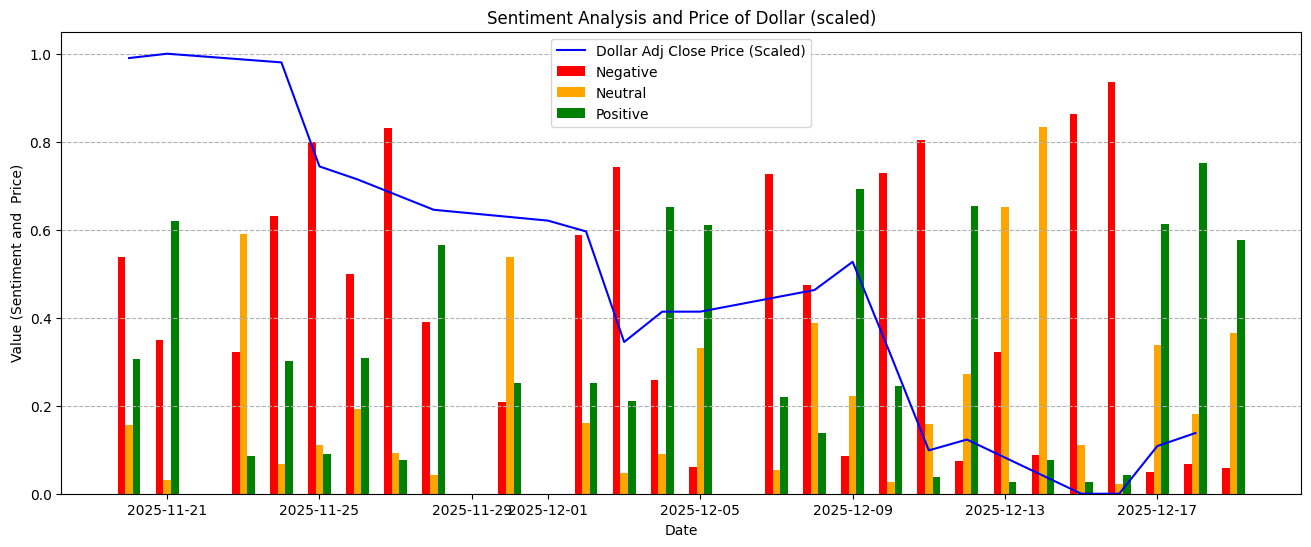

In [10]:
# Fetch Dollar data for the same date range
dollar = yf.download("DX-Y.NYB", start=df_grouped.index.min(), end=df_grouped.index.max())

# Scale the Microsoft price data
scaler = MinMaxScaler()
scaled_stock_price = scaler.fit_transform(dollar[['Close']])

# Plot scaled price plot
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(dollar.index, scaled_stock_price, color='blue', label='Dollar Adj Close Price (Scaled)')

# Plot the sentiment data
width = 0.2  # Adjust the width as needed
ax.bar(df_grouped.index - pd.DateOffset(days=width), df_grouped['avg_negative'], width=width, label='Negative', color='red')
ax.bar(df_grouped.index, df_grouped['avg_neutral'], width=width, label='Neutral', color='orange')
ax.bar(df_grouped.index + pd.DateOffset(days=width), df_grouped['avg_positive'], width=width, label='Positive', color='green')

# Set plot attributes (labels, ticks, title, legend, gridlines)
ax.set_xlabel('Date')
ax.set_title('Sentiment Analysis and Price of Dollar (scaled)')
ax.set_ylabel('Value (Sentiment and  Price)')
ax.legend()
ax.grid(True, axis='y', linestyle='--')
plt.show()

In [15]:
# Preprocessing 'Description' column in df
df.loc[:, 'Processed_Description'] = df['Description'].apply(lambda x: preprocess(x))